In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Verify your project folder exists
import os

DRIVE_PATH = '/content/drive/MyDrive/graph_representation_project'

if os.path.exists(DRIVE_PATH):
    print("Folder found!")
    print("Contents:", os.listdir(DRIVE_PATH))
else:
    print("Folder not found — check the folder name in Drive")

Folder found!
Contents: ['HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'hmnist_8_8_L.csv', 'archive.zip', 'HAM10000_images_part_1', 'HAM10000_images_part_2', 'graphs', 'results.png', 'training_curves.json', 'sage_mean_final.pt', 'sage_sum_final.pt', 'sage_max_final.pt', 'gin_fixed_final.pt', 'gin_learn_final.pt', 'graphsage_mean_final.pt', 'graphsage_mean_curves.json', 'graphsage_mean_best.pt', 'gin_fixed_eps_final.pt', 'gin_fixed_eps_curves.json', 'gin_fixed_eps_best.pt', 'graphsage_sum_best.pt', 'graphsage_sum_final.pt', 'graphsage_sum_curves.json', 'graphsage_max_best.pt', 'graphsage_max_final.pt', 'graphsage_max_curves.json', 'gin_learnable_eps_best.pt', 'gin_learnable_eps_final.pt', 'gin_learnable_eps_curves.json', 'sage_mean_seed42_best.pt', 'sage_mean_seed42_final.pt', 'sage_mean_seed123_best.pt', 'sage_mean_seed123_final.pt', 'sage_mean_seed456_final.pt', 'seed_results_mean.json', 'sage_mean_seed456_best.pt', 'sage_sum_seed42_final

In [ ]:
import os

# Paths
PART1 = '/content/drive/MyDrive/graph_representation_project/HAM10000_images_part_1'
PART2 = '/content/drive/MyDrive/graph_representation_project/HAM10000_images_part_2'

# Count images
part1_images = os.listdir(PART1)
part2_images = os.listdir(PART2)

total = len(part1_images) + len(part2_images)

print(f"Part 1 images: {len(part1_images)}")
print(f"Part 2 images: {len(part2_images)}")
print(f"Total images: {total}")
print(f"Expected:      10015")

if total == 10015:
    print("All images present")
else:
    print(f"Missing {10015 - total} images")

Part 1 images: 5000
Part 2 images: 5015
Total images: 10015
Expected:      10015
All images present


In [ ]:
import os
import json

# Set up Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)


kaggle_creds = {
    "username": "your_kaggle_username",
    "key": "your_kaggle_key"
}

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)

os.system('chmod 600 ~/.kaggle/kaggle.json')
print("Kaggle credentials set up")

Kaggle credentials set up


In [ ]:
# Download directly to local storage
!pip install kaggle
!kaggle datasets download \
    -d kmader/skin-cancer-mnist-ham10000 \
    -p /content/HAM10000/ \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:28<00:00, 194MB/s]



In [ ]:
!pip install torch-geometric
!pip install torchvision
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install Pillow
!pip install tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00


In [ ]:
import os
print("Contents of HAM10000 folder:")
print(os.listdir('/content/HAM10000'))

Contents of HAM10000 folder:
['HAM10000_images_part_1', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'HAM10000_images_part_2', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_metadata.csv']


In [ ]:
import os

base = '/content/HAM10000'

folders = [
    'HAM10000_images_part_1',
    'ham10000_images_part_1',
    'HAM10000_images_part_2',
    'ham10000_images_part_2'
]

for folder in folders:
    path = os.path.join(base, folder)
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"{folder}: {count} files")

HAM10000_images_part_1: 5000 files
ham10000_images_part_1: 5000 files
HAM10000_images_part_2: 5015 files
ham10000_images_part_2: 5015 files


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import shutil

from PIL import Image
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# Fixed deprecated import
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GINConv
from torch_geometric.nn import (global_mean_pool,
                                 global_add_pool,
                                 global_max_pool)

from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, precision_score,
                             recall_score, confusion_matrix)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
# Global seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Drive paths
DRIVE_PATH = '/content/drive/MyDrive/graph_representation_project'
IMAGES_PATH_1 = f'{DRIVE_PATH}/HAM10000_images_part_1'
IMAGES_PATH_2 = f'{DRIVE_PATH}/HAM10000_images_part_2'
METADATA_PATH = f'{DRIVE_PATH}/HAM10000_metadata.csv'
GRAPHS_SAVE_PATH = f'{DRIVE_PATH}/graphs'

# Local paths — updated to Kaggle download location
LOCAL_PATH = '/content/HAM10000'
LOCAL_PART1 = f'{LOCAL_PATH}/HAM10000_images_part_1'
LOCAL_PART2 = f'{LOCAL_PATH}/HAM10000_images_part_2'

# Create graphs directory
os.makedirs(GRAPHS_SAVE_PATH, exist_ok=True)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Hyperparameters
PATCH_SIZE = 32
K_NEIGHBORS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 100
NUM_CLASSES = 7

print("Configuration set")

Using device: cuda
Configuration set


In [ ]:
# Load metadata
df = pd.read_csv(METADATA_PATH)

# Quick check
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['dx'].value_counts())
print(f"\nSample rows:")
print(df.head())

Total records: 10015
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Sample rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [ ]:
# Encode labels
label_mapping = {
    'nv': 0,
    'mel': 1,
    'bkl': 2,
    'bcc': 3,
    'akiec': 4,
    'vasc': 5,
    'df': 6
}

df['label'] = df['dx'].map(label_mapping)

# Create image path lookup
def get_image_path(image_id):
    path1 = os.path.join(IMAGES_PATH_1, f'{image_id}.jpg')
    path2 = os.path.join(IMAGES_PATH_2, f'{image_id}.jpg')
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    return None

df['image_path'] = df['image_id'].apply(get_image_path)

# Check for missing images
missing = df['image_path'].isna().sum()
print(f"Missing images: {missing}")
print(f"Labels encoded successfully")
print(df[['image_id', 'dx', 'label', 'image_path']].head())

# Compute class weights for imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']),
    y=df['label']
)
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(DEVICE)
print(f"\nClass weights: {class_weights}")

Missing images: 0
Labels encoded successfully
       image_id   dx  label                                         image_path
0  ISIC_0027419  bkl      2  /content/drive/MyDrive/graph_representation_pr...
1  ISIC_0025030  bkl      2  /content/drive/MyDrive/graph_representation_pr...
2  ISIC_0026769  bkl      2  /content/drive/MyDrive/graph_representation_pr...
3  ISIC_0025661  bkl      2  /content/drive/MyDrive/graph_representation_pr...
4  ISIC_0031633  bkl      2  /content/drive/MyDrive/graph_representation_pr...

Class weights: tensor([ 0.2134,  1.2855,  1.3018,  2.7835,  4.3753, 10.0755, 12.4410],
       device='cuda:0')


In [ ]:
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Remove final classification layer
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(DEVICE)
resnet.eval()

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ResNet50 loaded successfully")
print(f"Feature vector size: 2048")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


ResNet50 loaded successfully
Feature vector size: 2048


In [ ]:
def extract_patches(image_path, patch_size=PATCH_SIZE):
    # Load image and transform once
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image)  # [3, 224, 224]

    # Extract patches using tensor slicing
    patches = []
    for i in range(0, 224 - patch_size, patch_size):
        for j in range(0, 224 - patch_size, patch_size):
            patch = image_tensor[
                :,
                i:i+patch_size,
                j:j+patch_size
            ]
            patches.append(patch.unsqueeze(0))

    return patches

def extract_features_batch(patches):
    # Process all patches in one GPU call
    batch = torch.cat(patches, dim=0).to(DEVICE)
    with torch.no_grad():
        features = resnet(batch)
        features = features.squeeze().cpu().numpy()
    return features

# Test on one image
test_path = df['image_path'].iloc[0]
test_patches = extract_patches(test_path)
test_features = extract_features_batch(test_patches)

print(f"Number of patches per image: {len(test_patches)}")
print(f"Feature vector shape: {test_features.shape}")
print("Patch extraction working correctly")

Number of patches per image: 36
Feature vector shape: (36, 2048)
Patch extraction working correctly


In [ ]:
def build_graph_torch_knn(features, label, k=K_NEIGHBORS):
    # Convert to GPU tensor
    features_tensor = torch.tensor(
        features,
        dtype=torch.float32
    ).to(DEVICE)

    # Compute pairwise distances on GPU
    dist_matrix = torch.cdist(
        features_tensor,
        features_tensor
    )

    # Get k nearest neighbours
    _, indices = torch.topk(
        dist_matrix,
        k=k+1,
        largest=False
    )
    indices = indices[:, 1:]

    # Build edge index
    rows = torch.arange(
        features_tensor.shape[0]
    ).repeat_interleave(k).to(DEVICE)
    cols = indices.reshape(-1)

    edge_index = torch.stack([rows, cols]).cpu()
    x = torch.tensor(features, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

# Test on one image
test_graph = build_graph_torch_knn(
    test_features,
    df['label'].iloc[0]
)

print(f"Number of nodes: {test_graph.num_nodes}")
print(f"Number of edges: {test_graph.num_edges}")
print(f"Node feature size: {test_graph.x.shape}")
print(f"Label: {test_graph.y}")
print("Graph construction working correctly")

Number of nodes: 36
Number of edges: 180
Node feature size: torch.Size([36, 2048])
Label: tensor([2])
Graph construction working correctly


In [ ]:
def build_all_graphs_torch(df, save_path):
    save_file = os.path.join(save_path, 'all_graphs.pkl')

    # Check cache first
    if os.path.exists(save_file):
        print("Cached graphs found — loading from Drive...")
        with open(save_file, 'rb') as f:
            graphs = pickle.load(f)
        print(f"Loaded {len(graphs)} graphs from cache")
        return graphs

    # Build from scratch
    print("No cache found — building graphs...")
    graphs = []
    failed = []

    for idx, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Building graphs"
    ):
        try:
            patches = extract_patches(row['image_path'])
            features = extract_features_batch(patches)
            graph = build_graph_torch_knn(
                features,
                row['label']
            )
            graphs.append(graph)
        except Exception as e:
            failed.append(idx)
            print(f"Failed on index {idx}: {e}")

    # Save to Drive
    with open(save_file, 'wb') as f:
        pickle.dump(graphs, f)

    print(f"Total graphs built: {len(graphs)}")
    print(f"Failed: {len(failed)}")
    print(f"Saved to: {save_file}")

    return graphs

graphs = build_all_graphs_torch(df, GRAPHS_SAVE_PATH)

Cached graphs found — loading from Drive...
Loaded 10015 graphs from cache


In [ ]:
import sys

def copy_with_progress(src, dst, part_name):
    src_count = len(os.listdir(src))
    dst_count = len(os.listdir(dst))

    # Only skip if ALL files are already copied
    if dst_count == src_count:
        print(f"{part_name}: Already copied ({dst_count} files) — skipping")
        return dst_count

    # Otherwise copy missing files
    print(f"{part_name}: Found {dst_count}/{src_count} — copying remaining...")
    files = os.listdir(src)
    total = len(files)
    copied = 0

    for i, file in enumerate(files):
        dest_file = os.path.join(dst, file)
        # Only copy if not already there
        if not os.path.exists(dest_file):
            shutil.copy2(
                os.path.join(src, file),
                dest_file
            )
            copied += 1

        if (i + 1) % 100 == 0:
            print(f"{part_name}: {i+1}/{total} checked")
            sys.stdout.flush()

    print(f"{part_name}: Done - copied {copied} new files")
    sys.stdout.flush()
    return len(os.listdir(dst))

# Copy part 1
print("Starting Part 1...")
sys.stdout.flush()
count1 = copy_with_progress(IMAGES_PATH_1, LOCAL_PART1, "Part 1")

# Copy part 2
print("\nStarting Part 2...")
sys.stdout.flush()
count2 = copy_with_progress(IMAGES_PATH_2, LOCAL_PART2, "Part 2")

# Verify
total = count1 + count2
print(f"\nTotal copied: {total}/10015")
if total == 10015:
    print("All images present in local storage")
else:
    print(f"Warning: Missing {10015 - total} images")

Starting Part 1...
Part 1: Already copied (5000 files) — skipping

Starting Part 2...
Part 2: Already copied (5015 files) — skipping

Total copied: 10015/10015
All images present in local storage


In [ ]:
def get_local_image_path(image_id):
    path1 = os.path.join(LOCAL_PART1, f'{image_id}.jpg')
    path2 = os.path.join(LOCAL_PART2, f'{image_id}.jpg')
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    return None

df['image_path'] = df['image_id'].apply(get_local_image_path)

missing = df['image_path'].isna().sum()
print(f"Missing images: {missing}")
print(f"Sample path: {df['image_path'].iloc[0]}")

Missing images: 0
Sample path: /content/HAM10000/HAM10000_images_part_1/ISIC_0027419.jpg


In [ ]:
def extract_patches(image_path, patch_size=PATCH_SIZE):
    # Load and transform image once
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image)  # [3, 224, 224]

    # Extract patches using tensor slicing
    patches = []
    for i in range(0, 224 - patch_size, patch_size):
        for j in range(0, 224 - patch_size, patch_size):
            patch = image_tensor[
                :,
                i:i+patch_size,
                j:j+patch_size
            ]
            patches.append(patch.unsqueeze(0))

    return patches

def extract_features_batch(patches):
    # Process all patches in one GPU call
    batch = torch.cat(patches, dim=0).to(DEVICE)
    with torch.no_grad():
        features = resnet(batch)
        features = features.squeeze().cpu().numpy()
    return features

# Verify patch count
test_patches = extract_patches(df['image_path'].iloc[0])
test_features = extract_features_batch(test_patches)

print(f"Number of patches: {len(test_patches)}")
print(f"Feature shape: {test_features.shape}")
print("Extraction functions ready")

Number of patches: 36
Feature shape: (36, 2048)
Extraction functions ready


In [ ]:
def build_graph_torch_knn(features, label, k=K_NEIGHBORS):
    features_tensor = torch.tensor(
        features,
        dtype=torch.float32
    ).to(DEVICE)

    dist_matrix = torch.cdist(features_tensor, features_tensor)

    _, indices = torch.topk(
        dist_matrix,
        k=k+1,
        largest=False
    )
    indices = indices[:, 1:]

    rows = torch.arange(
        features_tensor.shape[0]
    ).repeat_interleave(k).to(DEVICE)
    cols = indices.reshape(-1)

    edge_index = torch.stack([rows, cols]).cpu()
    x = torch.tensor(features, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

print("Graph construction function ready")

Graph construction function ready


In [ ]:
def build_all_graphs_torch(df, save_path):
    save_file = os.path.join(save_path, 'all_graphs.pkl')

    # Check if graphs already exist
    if os.path.exists(save_file):
        print("Cached graphs found — loading from Drive...")
        with open(save_file, 'rb') as f:
            graphs = pickle.load(f)
        print(f"Loaded {len(graphs)} graphs from cache")
        return graphs

    # If not cached, build from scratch
    print("No cache found — building graphs...")
    graphs = []
    failed = []

    for idx, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Building graphs"
    ):
        try:
            patches = extract_patches(row['image_path'])
            features = extract_features_batch(patches)
            graph = build_graph_torch_knn(
                features,
                row['label']
            )
            graphs.append(graph)
        except Exception as e:
            failed.append(idx)
            print(f"Failed on index {idx}: {e}")

    # Save to Drive
    with open(save_file, 'wb') as f:
        pickle.dump(graphs, f)

    print(f"Total graphs built: {len(graphs)}")
    print(f"Failed: {len(failed)}")
    print(f"Saved to: {save_file}")

    return graphs

# Delete old cache since patch extraction method changed
old_cache = os.path.join(GRAPHS_SAVE_PATH, 'all_graphs.pkl')
if os.path.exists(old_cache):
    os.remove(old_cache)
    print("Old cache deleted — will rebuild with corrected pipeline")

graphs = build_all_graphs_torch(df, GRAPHS_SAVE_PATH)

Old cache deleted — will rebuild with corrected pipeline
No cache found — building graphs...


Building graphs: 100%|██████████| 10015/10015 [03:12<00:00, 52.08it/s]


Total graphs built: 10015
Failed: 0
Saved to: /content/drive/MyDrive/graph_representation_project/graphs/all_graphs.pkl


In [ ]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# Split into train, val, test
train_graphs, test_graphs = train_test_split(
    graphs,
    test_size=0.15,
    random_state=42
)
train_graphs, val_graphs = train_test_split(
    train_graphs,
    test_size=0.15,
    random_state=42
)

train_loader = DataLoader(
    train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train graphs: {len(train_graphs)}")
print(f"Val graphs:   {len(val_graphs)}")
print(f"Test graphs:  {len(test_graphs)}")

Train graphs: 7235
Val graphs:   1277
Test graphs:  1503


In [ ]:
class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden_channels,
                 num_classes, aggr='mean'):
        super(GraphSAGEModel, self).__init__()
        self.aggr = aggr
        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels,
            aggr=aggr
        )
        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels,
            aggr=aggr
        )
        self.classifier = nn.Linear(
            hidden_channels,
            num_classes
        )
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Match readout pooling to aggregation type
        if self.aggr == 'mean':
            x = global_mean_pool(x, batch)
        elif self.aggr == 'sum':
            x = global_add_pool(x, batch)
        elif self.aggr == 'max':
            x = global_max_pool(x, batch)

        x = self.classifier(x)
        return x

print("GraphSAGE model defined")

GraphSAGE model defined


In [ ]:
class GINModel(nn.Module):
    def __init__(self, in_channels, hidden_channels,
                 num_classes, eps=0.0, train_eps=False):
        super(GINModel, self).__init__()
        self.train_eps = train_eps

        nn1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        nn2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )

        self.conv1 = GINConv(
            nn1,
            eps=eps,
            train_eps=train_eps
        )
        self.conv2 = GINConv(
            nn2,
            eps=eps,
            train_eps=train_eps
        )
        self.classifier = nn.Linear(
            hidden_channels,
            num_classes
        )
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_add_pool(x, batch)
        x = self.classifier(x)
        return x

print("GIN model defined")

GIN model defined


In [ ]:
def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LEARNING_RATE,
                model_name='model'):
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0

    epoch_bar = tqdm(range(epochs), desc="Epochs")

    for epoch in epoch_bar:
        # Training
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.y.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                out = model(
                    batch.x,
                    batch.edge_index,
                    batch.batch
                )
                loss = criterion(out, batch.y)
                val_loss += loss.item()
                pred = out.argmax(dim=1)
                val_correct += (pred == batch.y).sum().item()
                val_total += batch.y.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                model.state_dict(),
                f'{DRIVE_PATH}/{model_name}_best.pt'
            )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Update progress bar
        epoch_bar.set_postfix({
            'TLoss': f'{train_loss:.4f}',
            'TAcc': f'{train_acc:.4f}',
            'VLoss': f'{val_loss:.4f}',
            'VAcc': f'{val_acc:.4f}',
            'Best': f'{best_val_acc:.4f}'
        })

    return train_losses, val_losses, train_accs, val_accs

print("Training function ready")

Training function ready


In [ ]:
import os

def load_or_train(model, model_name, train_loader,
                  val_loader, epochs, lr):
    save_path = os.path.join(DRIVE_PATH, f'{model_name}_final.pt')
    curves_path = os.path.join(DRIVE_PATH, f'{model_name}_curves.json')

    # Check if already trained
    if os.path.exists(save_path) and os.path.exists(curves_path):
        print(f"{model_name}: Loading from cache...")
        model.load_state_dict(
            torch.load(save_path, map_location=DEVICE)
        )
        with open(curves_path, 'r') as f:
            curves = json.load(f)
        print(f"{model_name}: Loaded successfully")
        return (
            curves['train_losses'],
            curves['val_losses'],
            curves['train_accs'],
            curves['val_accs']
        )

    # Train from scratch
    print(f"{model_name}: No cache found — training...")
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader,
        epochs=epochs, lr=lr,
        model_name=model_name
    )

    # Save model
    torch.save(
        model.state_dict(),
        save_path
    )

    # Save curves
    curves = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    with open(curves_path, 'w') as f:
        json.dump(curves, f)

    print(f"{model_name}: Saved to cache")
    return train_losses, val_losses, train_accs, val_accs

# Train GraphSAGE mean
print("Training GraphSAGE (mean)...")
sage_model = GraphSAGEModel(
    in_channels=2048,
    hidden_channels=256,
    num_classes=NUM_CLASSES,
    aggr='mean'
).to(DEVICE)

sage_losses, sage_val_losses, sage_accs, sage_val_accs = load_or_train(
    sage_model, 'graphsage_mean',
    train_loader, val_loader,
    EPOCHS, LEARNING_RATE
)

# Train GIN fixed epsilon
print("\nTraining GIN (fixed epsilon)...")
gin_model = GINModel(
    in_channels=2048,
    hidden_channels=256,
    num_classes=NUM_CLASSES,
    eps=0.0,
    train_eps=False
).to(DEVICE)

gin_losses, gin_val_losses, gin_accs, gin_val_accs = load_or_train(
    gin_model, 'gin_fixed_eps',
    train_loader, val_loader,
    EPOCHS, LEARNING_RATE
)

Training GraphSAGE (mean)...
graphsage_mean: Loading from cache...
graphsage_mean: Loaded successfully

Training GIN (fixed epsilon)...
gin_fixed_eps: Loading from cache...
gin_fixed_eps: Loaded successfully


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(DEVICE)
            out = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )
            probs = F.softmax(out, dim=1)
            pred = out.argmax(dim=1)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(
        all_labels, all_preds, average='weighted'
    )
    recall = recall_score(
        all_labels, all_preds, average='weighted'
    )
    labels_bin = label_binarize(
        all_labels,
        classes=list(range(NUM_CLASSES))
    )
    auc = roc_auc_score(
        labels_bin,
        all_probs,
        multi_class='ovr'
    )

    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {auc:.4f}")

    return all_preds, all_labels, all_probs

print("Evaluating GraphSAGE (mean)...")
sage_preds, sage_labels, sage_probs = evaluate_model(
    sage_model, test_loader
)

print("\nEvaluating GIN (fixed epsilon)...")
gin_preds, gin_labels, gin_probs = evaluate_model(
    gin_model, test_loader
)

Evaluating GraphSAGE (mean)...
Accuracy:  0.7878
F1 Score:  0.7938
Precision: 0.8133
Recall:    0.7878
AUC:       0.9467

Evaluating GIN (fixed epsilon)...
Accuracy:  0.7764
F1 Score:  0.7743
Precision: 0.7781
Recall:    0.7764
AUC:       0.9327


In [ ]:
# GraphSAGE SUM
print("Training GraphSAGE (sum)...")
sage_sum = GraphSAGEModel(
    in_channels=2048,
    hidden_channels=256,
    num_classes=NUM_CLASSES,
    aggr='sum'
).to(DEVICE)

sage_sum_losses, sage_sum_val_losses, sage_sum_accs, sage_sum_val_accs = load_or_train(
    sage_sum, 'graphsage_sum',
    train_loader, val_loader,
    EPOCHS, LEARNING_RATE
)

# GraphSAGE MAX
print("\nTraining GraphSAGE (max)...")
sage_max = GraphSAGEModel(
    in_channels=2048,
    hidden_channels=256,
    num_classes=NUM_CLASSES,
    aggr='max'
).to(DEVICE)

sage_max_losses, sage_max_val_losses, sage_max_accs, sage_max_val_accs = load_or_train(
    sage_max, 'graphsage_max',
    train_loader, val_loader,
    EPOCHS, LEARNING_RATE
)

# GIN learnable epsilon
print("\nTraining GIN (learnable epsilon)...")
gin_learn = GINModel(
    in_channels=2048,
    hidden_channels=256,
    num_classes=NUM_CLASSES,
    eps=0.0,
    train_eps=True
).to(DEVICE)

gin_learn_losses, gin_learn_val_losses, gin_learn_accs, gin_learn_val_accs = load_or_train(
    gin_learn, 'gin_learnable_eps',
    train_loader, val_loader,
    EPOCHS, LEARNING_RATE
)

Training GraphSAGE (sum)...
graphsage_sum: Loading from cache...
graphsage_sum: Loaded successfully

Training GraphSAGE (max)...
graphsage_max: Loading from cache...
graphsage_max: Loaded successfully

Training GIN (learnable epsilon)...
gin_learnable_eps: Loading from cache...
gin_learnable_eps: Loaded successfully


In [ ]:
print("Evaluating GraphSAGE (sum)...")
sage_sum_preds, sage_sum_labels, sage_sum_probs = evaluate_model(
    sage_sum, test_loader
)

print("\nEvaluating GraphSAGE (max)...")
sage_max_preds, sage_max_labels, sage_max_probs = evaluate_model(
    sage_max, test_loader
)

print("\nEvaluating GIN (learnable epsilon)...")
gin_learn_preds, gin_learn_labels, gin_learn_probs = evaluate_model(
    gin_learn, test_loader
)

Evaluating GraphSAGE (sum)...
Accuracy:  0.6906
F1 Score:  0.7064
Precision: 0.7335
Recall:    0.6906
AUC:       0.8803

Evaluating GraphSAGE (max)...
Accuracy:  0.7911
F1 Score:  0.7726
Precision: 0.7772
Recall:    0.7911
AUC:       0.9459

Evaluating GIN (learnable epsilon)...
Accuracy:  0.6966
F1 Score:  0.7163
Precision: 0.7696
Recall:    0.6966
AUC:       0.9006


In [ ]:
def run_multiple_seeds(aggr, seeds=[42, 123, 456]):
    cache_file = os.path.join(
        DRIVE_PATH,
        f'seed_results_{aggr}.json'
    )

    # Check cache first
    if os.path.exists(cache_file):
        print(f"{aggr}: Loading seed results from cache...")
        with open(cache_file, 'r') as f:
            data = json.load(f)
        accs = data['accs']
        print(f"Mean: {np.mean(accs):.4f}")
        print(f"Std:  {np.std(accs):.4f}")
        return accs

    # Run from scratch
    accs = []
    for seed in seeds:
        model_name = f'sage_{aggr}_seed{seed}'
        model_path = os.path.join(
            DRIVE_PATH,
            f'{model_name}_final.pt'
        )

        torch.manual_seed(seed)
        np.random.seed(seed)

        model = GraphSAGEModel(
            in_channels=2048,
            hidden_channels=256,
            num_classes=NUM_CLASSES,
            aggr=aggr
        ).to(DEVICE)

        # Check if individual model cached
        if os.path.exists(model_path):
            print(f"Seed {seed}: Loading model from cache...")
            model.load_state_dict(
                torch.load(model_path, map_location=DEVICE)
            )
        else:
            print(f"Seed {seed}: Training...")
            train_model(
                model, train_loader, val_loader,
                epochs=EPOCHS, lr=LEARNING_RATE,
                model_name=model_name
            )
            torch.save(model.state_dict(), model_path)

        preds, labels, probs = evaluate_model(
            model, test_loader
        )
        acc = accuracy_score(labels, preds)
        accs.append(acc)
        print(f"Seed {seed}: {acc:.4f}")

    # Save all seed results
    with open(cache_file, 'w') as f:
        json.dump({'aggr': aggr, 'accs': accs}, f)

    print(f"\nAggregation: {aggr}")
    print(f"Mean: {np.mean(accs):.4f}")
    print(f"Std:  {np.std(accs):.4f}")

    return accs

print("Running MEAN aggregation across seeds...")
mean_seed_accs = run_multiple_seeds('mean')

print("\nRunning SUM aggregation across seeds...")
sum_seed_accs = run_multiple_seeds('sum')

print("\nRunning MAX aggregation across seeds...")
max_seed_accs = run_multiple_seeds('max')

Running MEAN aggregation across seeds...
mean: Loading seed results from cache...
Mean: 0.7838
Std:  0.0104

Running SUM aggregation across seeds...
sum: Loading seed results from cache...
Mean: 0.6990
Std:  0.0163

Running MAX aggregation across seeds...
max: Loading seed results from cache...
Mean: 0.7929
Std:  0.0035


In [ ]:
import json

# Save predictions — not saved anywhere else
predictions = {
    'sage_mean': {
        'preds': sage_preds.tolist(),
        'labels': sage_labels.tolist(),
        'probs': sage_probs.tolist()
    },
    'sage_sum': {
        'preds': sage_sum_preds.tolist(),
        'labels': sage_sum_labels.tolist(),
        'probs': sage_sum_probs.tolist()
    },
    'sage_max': {
        'preds': sage_max_preds.tolist(),
        'labels': sage_max_labels.tolist(),
        'probs': sage_max_probs.tolist()
    },
    'gin_fixed': {
        'preds': gin_preds.tolist(),
        'labels': gin_labels.tolist(),
        'probs': gin_probs.tolist()
    },
    'gin_learn': {
        'preds': gin_learn_preds.tolist(),
        'labels': gin_learn_labels.tolist(),
        'probs': gin_learn_probs.tolist()
    }
}

pred_file = os.path.join(DRIVE_PATH, 'predictions.json')
with open(pred_file, 'w') as f:
    json.dump(predictions, f)
print("Predictions saved")

# Save seed results — already saved per aggregation
# but save combined version for easy loading
seed_results = {
    'mean': mean_seed_accs,
    'sum': sum_seed_accs,
    'max': max_seed_accs
}

seed_file = os.path.join(DRIVE_PATH, 'seed_results.json')
with open(seed_file, 'w') as f:
    json.dump(seed_results, f)
print("Seed results saved")

print("\nAll cached successfully")

Predictions saved
Seed results saved

All cached successfully


In [ ]:
# Reload predictions
with open(os.path.join(DRIVE_PATH, 'predictions.json'), 'r') as f:
    predictions = json.load(f)

sage_preds = np.array(predictions['sage_mean']['preds'])
sage_labels = np.array(predictions['sage_mean']['labels'])
sage_probs = np.array(predictions['sage_mean']['probs'])

sage_sum_preds = np.array(predictions['sage_sum']['preds'])
sage_sum_labels = np.array(predictions['sage_sum']['labels'])
sage_sum_probs = np.array(predictions['sage_sum']['probs'])

sage_max_preds = np.array(predictions['sage_max']['preds'])
sage_max_labels = np.array(predictions['sage_max']['labels'])
sage_max_probs = np.array(predictions['sage_max']['probs'])

gin_preds = np.array(predictions['gin_fixed']['preds'])
gin_labels = np.array(predictions['gin_fixed']['labels'])
gin_probs = np.array(predictions['gin_fixed']['probs'])

gin_learn_preds = np.array(predictions['gin_learn']['preds'])
gin_learn_labels = np.array(predictions['gin_learn']['labels'])
gin_learn_probs = np.array(predictions['gin_learn']['probs'])

# Reload training curves from individual files
def load_curves(model_name):
    curves_path = os.path.join(
        DRIVE_PATH,
        f'{model_name}_curves.json'
    )
    with open(curves_path, 'r') as f:
        curves = json.load(f)
    return (
        curves['train_losses'],
        curves['val_losses'],
        curves['train_accs'],
        curves['val_accs']
    )

sage_losses, sage_val_losses, sage_accs, sage_val_accs = load_curves('graphsage_mean')
sage_sum_losses, sage_sum_val_losses, sage_sum_accs, sage_sum_val_accs = load_curves('graphsage_sum')
sage_max_losses, sage_max_val_losses, sage_max_accs, sage_max_val_accs = load_curves('graphsage_max')
gin_losses, gin_val_losses, gin_accs, gin_val_accs = load_curves('gin_fixed_eps')
gin_learn_losses, gin_learn_val_losses, gin_learn_accs, gin_learn_val_accs = load_curves('gin_learnable_eps')

# Reload seed results
with open(os.path.join(DRIVE_PATH, 'seed_results.json'), 'r') as f:
    seed_results = json.load(f)

mean_seed_accs = seed_results['mean']
sum_seed_accs = seed_results['sum']
max_seed_accs = seed_results['max']

print("All results reloaded successfully")

All results reloaded successfully


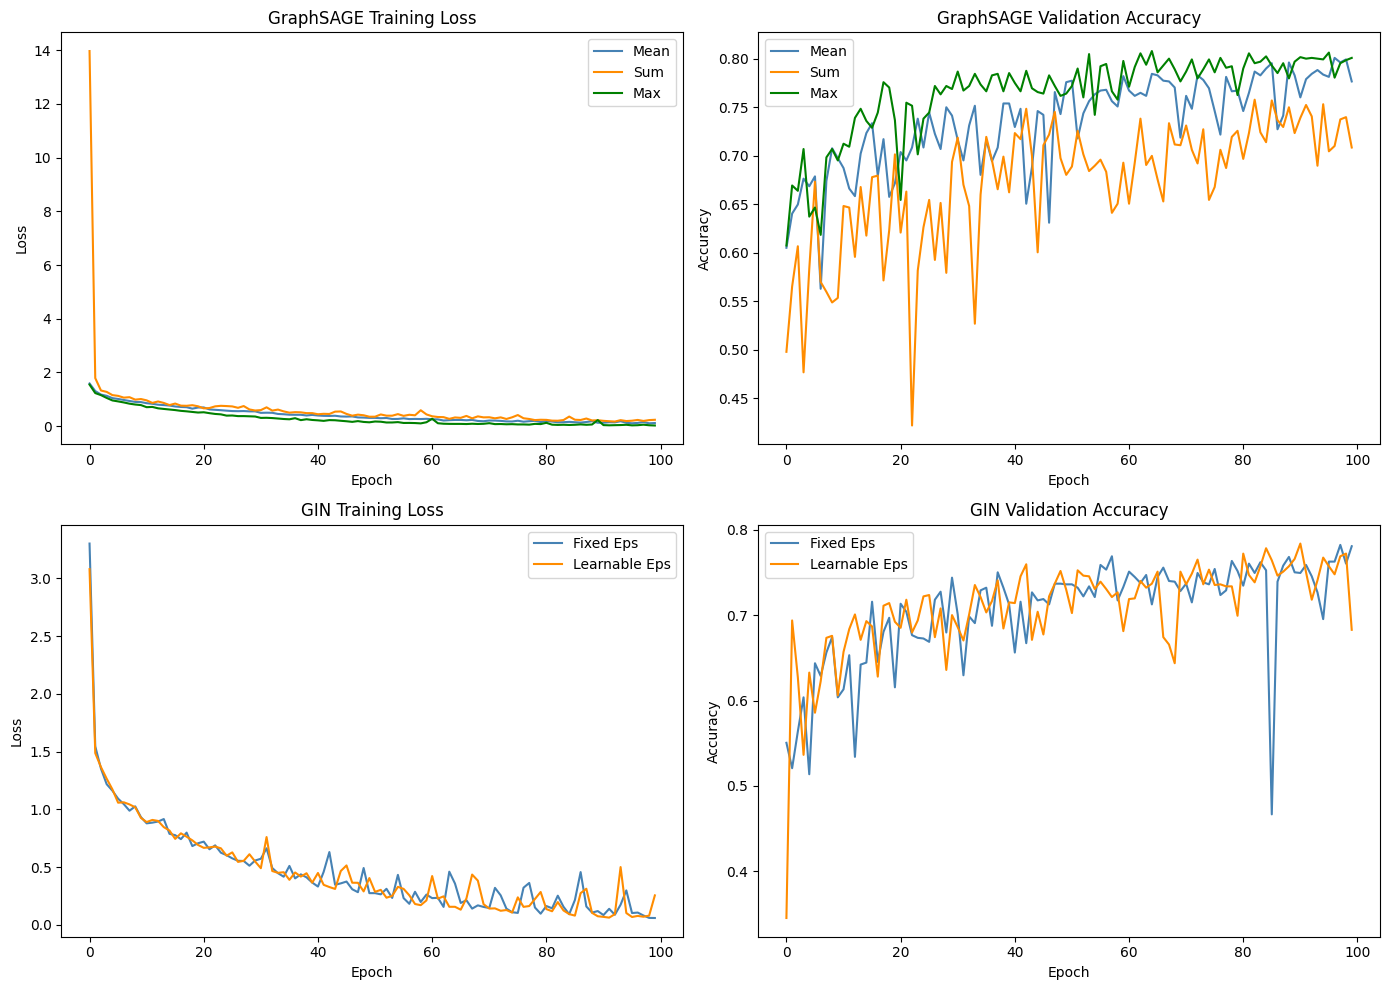

Training curves saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# GraphSAGE variants training loss
axes[0,0].plot(sage_losses, label='Mean', color='steelblue')
axes[0,0].plot(sage_sum_losses, label='Sum', color='darkorange')
axes[0,0].plot(sage_max_losses, label='Max', color='green')
axes[0,0].set_title('GraphSAGE Training Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

# GraphSAGE variants validation accuracy
axes[0,1].plot(sage_val_accs, label='Mean', color='steelblue')
axes[0,1].plot(sage_sum_val_accs, label='Sum', color='darkorange')
axes[0,1].plot(sage_max_val_accs, label='Max', color='green')
axes[0,1].set_title('GraphSAGE Validation Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# GIN variants training loss
axes[1,0].plot(gin_losses, label='Fixed Eps', color='steelblue')
axes[1,0].plot(gin_learn_losses, label='Learnable Eps', color='darkorange')
axes[1,0].set_title('GIN Training Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()

# GIN variants validation accuracy
axes[1,1].plot(gin_val_accs, label='Fixed Eps', color='steelblue')
axes[1,1].plot(gin_learn_val_accs, label='Learnable Eps', color='darkorange')
axes[1,1].set_title('GIN Validation Accuracy')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(
    os.path.join(DRIVE_PATH, 'training_curves.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Training curves saved")

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data from experiments
agg_names = ['Mean', 'Sum', 'Max']
agg_means = [
    np.mean(mean_seed_accs),
    np.mean(sum_seed_accs),
    np.mean(max_seed_accs)
]
agg_stds = [
    np.std(mean_seed_accs),
    np.std(sum_seed_accs),
    np.std(max_seed_accs)
]
seeds = ['Seed 42', 'Seed 123', 'Seed 456']
colors = ['steelblue', 'darkorange', 'green']

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Mean Accuracy by Aggregation',
        'Variance by Aggregation',
        'Per Seed Comparison'
    )
)

# Plot 1 — Mean accuracy with error bars
fig.add_trace(
    go.Bar(
        x=agg_names,
        y=agg_means,
        error_y=dict(
            type='data',
            array=agg_stds,
            visible=True
        ),
        name='Mean Accuracy',
        marker_color=colors,
        hovertemplate=(
            'Aggregation: %{x}<br>'
            'Mean: %{y:.4f}<br>'
            '<extra></extra>'
        )
    ),
    row=1, col=1
)

# Plot 2 — Variance
fig.add_trace(
    go.Bar(
        x=agg_names,
        y=agg_stds,
        name='Std Dev',
        marker_color=colors,
        hovertemplate=(
            'Aggregation: %{x}<br>'
            'Std: %{y:.4f}<br>'
            '<extra></extra>'
        )
    ),
    row=1, col=2
)

# Plot 3 — Per seed
for accs, name, color in zip(
    [mean_seed_accs, sum_seed_accs, max_seed_accs],
    agg_names,
    colors
):
    fig.add_trace(
        go.Bar(
            name=name,
            x=seeds,
            y=accs,
            marker_color=color,
            hovertemplate=(
                f'Aggregation: {name}<br>'
                'Seed: %{x}<br>'
                'Accuracy: %{y:.4f}<br>'
                '<extra></extra>'
            )
        ),
        row=1, col=3
    )

fig.update_layout(
    title='GraphSAGE Aggregation Function Comparison',
    height=500,
    showlegend=True,
    barmode='group',
    template='plotly_white'
)

fig.write_html(
    os.path.join(DRIVE_PATH, 'aggregation_comparison.html')
)
fig.show()
print("Aggregation comparison saved")

Aggregation comparison saved


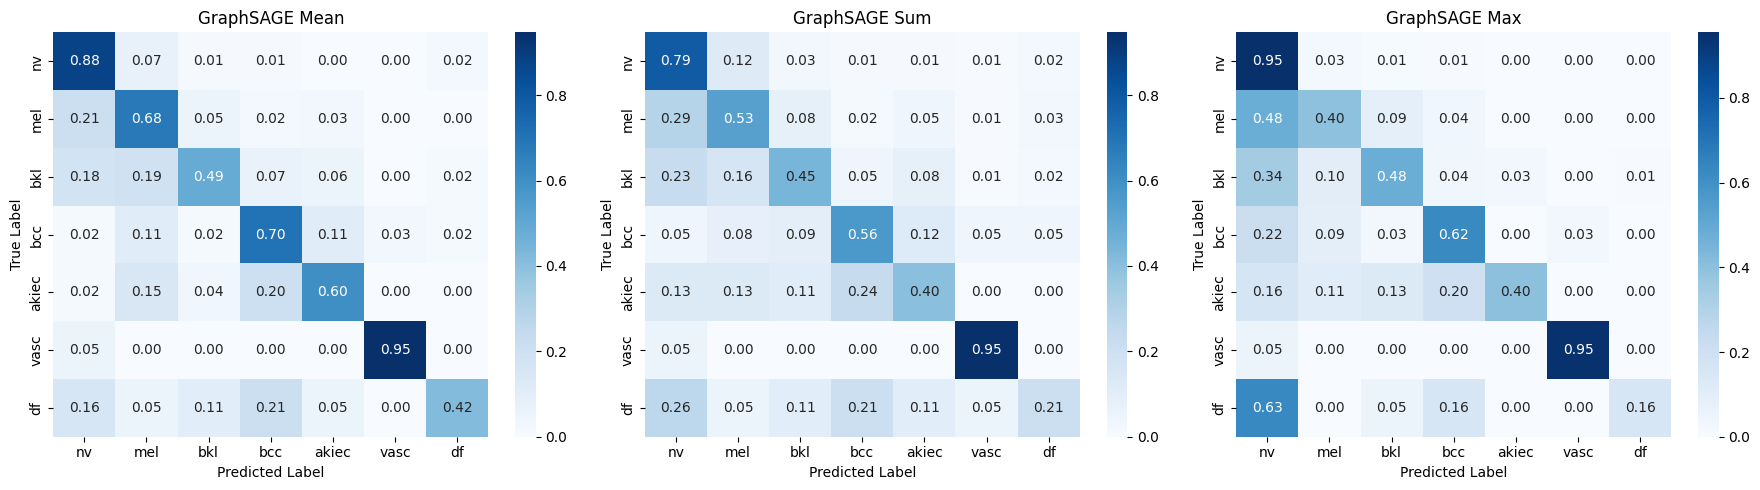

Confusion matrices saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

models_data = [
    (sage_preds, sage_labels, 'GraphSAGE Mean'),
    (sage_sum_preds, sage_sum_labels, 'GraphSAGE Sum'),
    (sage_max_preds, sage_max_labels, 'GraphSAGE Max')
]

for ax, (preds, labels, title) in zip(axes, models_data):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(
    os.path.join(DRIVE_PATH, 'confusion_matrices.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Confusion matrices saved")

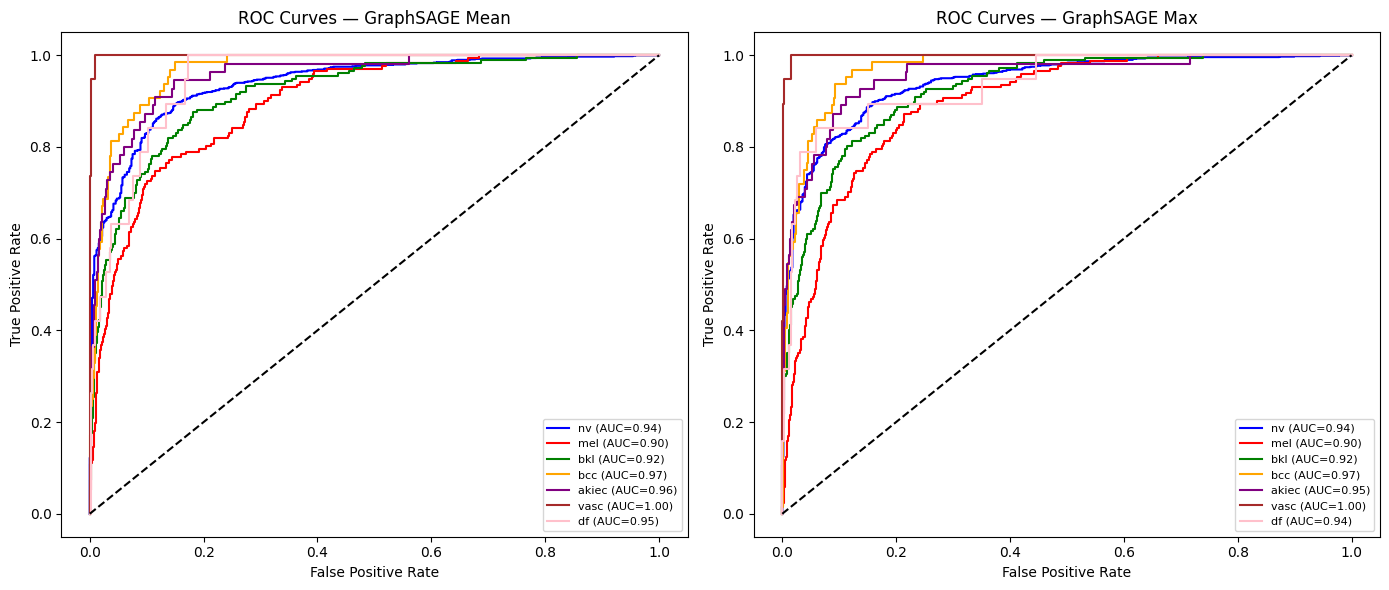

ROC curves saved


In [ ]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
colors_roc = [
    'blue', 'red', 'green',
    'orange', 'purple', 'brown', 'pink'
]

models_roc = [
    (sage_labels, sage_probs, 'GraphSAGE Mean'),
    (sage_max_labels, sage_max_probs, 'GraphSAGE Max')
]

for ax, (labels, probs, title) in zip(axes, models_roc):
    labels_bin = label_binarize(
        labels,
        classes=list(range(NUM_CLASSES))
    )
    for i, (class_name, color) in enumerate(
        zip(class_names, colors_roc)
    ):
        fpr, tpr, _ = roc_curve(
            labels_bin[:, i],
            probs[:, i]
        )
        auc = roc_auc_score(
            labels_bin[:, i],
            probs[:, i]
        )
        ax.plot(
            fpr, tpr,
            color=color,
            label=f'{class_name} (AUC={auc:.2f})'
        )

    ax.plot([0,1], [0,1], 'k--')
    ax.set_title(f'ROC Curves — {title}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(DRIVE_PATH, 'roc_curves.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("ROC curves saved")

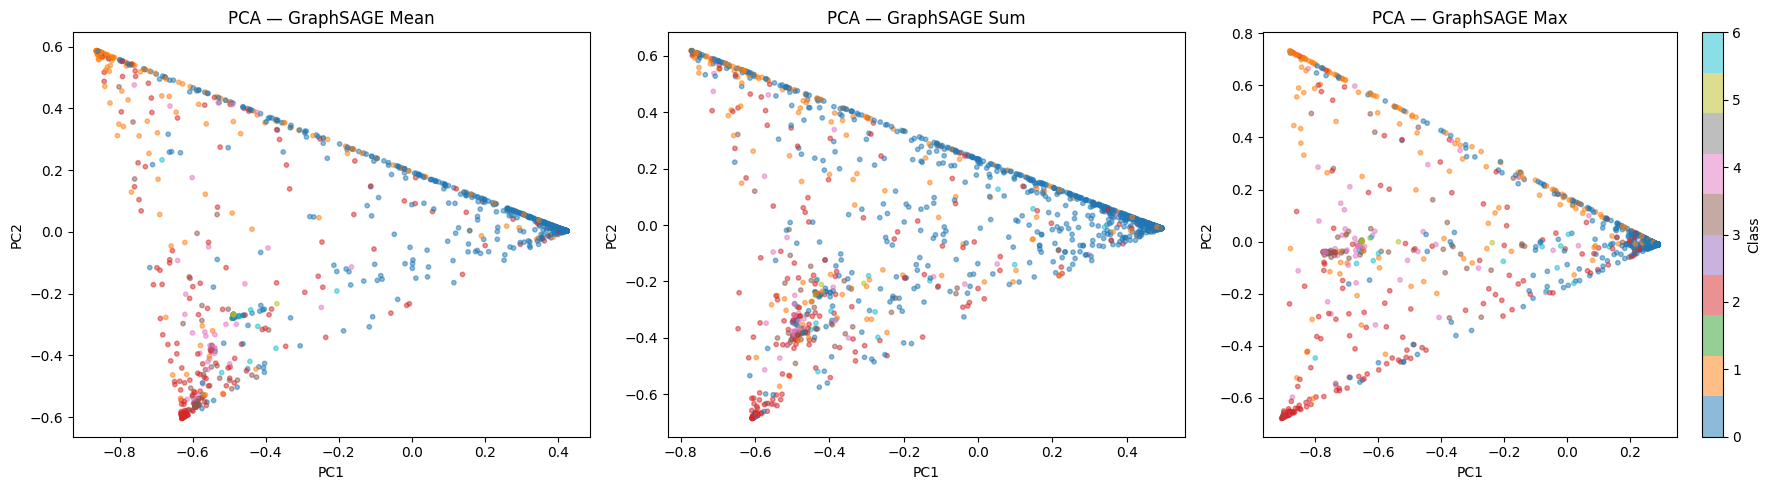

PCA plots saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pca = PCA(n_components=2)

models_pca = [
    (sage_probs, sage_labels, 'GraphSAGE Mean'),
    (sage_sum_probs, sage_sum_labels, 'GraphSAGE Sum'),
    (sage_max_probs, sage_max_labels, 'GraphSAGE Max')
]

class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

for ax, (probs, labels, title) in zip(axes, models_pca):
    pca_result = pca.fit_transform(probs)

    scatter = ax.scatter(
        pca_result[:, 0],
        pca_result[:, 1],
        c=labels,
        cmap='tab10',
        alpha=0.5,
        s=10
    )
    ax.set_title(f'PCA — {title}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.colorbar(scatter, ax=axes[-1], label='Class')
plt.tight_layout()
plt.savefig(
    os.path.join(DRIVE_PATH, 'pca_plots.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("PCA plots saved")

In [ ]:
from scipy import stats

def run_gin_seeds(train_eps, seeds=[42, 123, 456]):
    eps_name = "learn" if train_eps else "fixed"
    cache_file = os.path.join(
        DRIVE_PATH,
        f'seed_results_gin_{eps_name}.json'
    )

    # Check cache first
    if os.path.exists(cache_file):
        print(f"GIN {eps_name}: Loading from cache...")
        with open(cache_file, 'r') as f:
            data = json.load(f)
        accs = data['accs']
        print(f"Mean: {np.mean(accs):.4f}")
        print(f"Std:  {np.std(accs):.4f}")
        return accs

    # Run from scratch
    accs = []
    for seed in seeds:
        model_name = f'gin_{eps_name}_seed{seed}'
        model_path = os.path.join(
            DRIVE_PATH,
            f'{model_name}_final.pt'
        )

        torch.manual_seed(seed)
        np.random.seed(seed)

        model = GINModel(
            in_channels=2048,
            hidden_channels=256,
            num_classes=NUM_CLASSES,
            eps=0.0,
            train_eps=train_eps
        ).to(DEVICE)

        # Check individual model cache
        if os.path.exists(model_path):
            print(f"Seed {seed}: Loading from cache...")
            model.load_state_dict(
                torch.load(model_path, map_location=DEVICE)
            )
        else:
            print(f"Seed {seed}: Training...")
            train_model(
                model, train_loader, val_loader,
                epochs=EPOCHS, lr=LEARNING_RATE,
                model_name=model_name
            )
            torch.save(model.state_dict(), model_path)

        preds, labels, probs = evaluate_model(
            model, test_loader
        )
        acc = accuracy_score(labels, preds)
        accs.append(acc)
        print(f"Seed {seed}: {acc:.4f}")

    # Save results
    with open(cache_file, 'w') as f:
        json.dump({'eps': eps_name, 'accs': accs}, f)

    print(f"\nGIN {eps_name}")
    print(f"Mean: {np.mean(accs):.4f}")
    print(f"Std:  {np.std(accs):.4f}")

    return accs

print("Running GIN fixed epsilon across seeds...")
gin_fixed_seed_accs = run_gin_seeds(train_eps=False)

print("\nRunning GIN learnable epsilon across seeds...")
gin_learn_seed_accs = run_gin_seeds(train_eps=True)

Running GIN fixed epsilon across seeds...
GIN fixed: Loading from cache...
Mean: 0.7458
Std:  0.0342

Running GIN learnable epsilon across seeds...
GIN learn: Loading from cache...
Mean: 0.7616
Std:  0.0169


In [ ]:
from scipy import stats

# All results with seeds
all_results = {
    'GraphSAGE Mean': mean_seed_accs,
    'GraphSAGE Sum': sum_seed_accs,
    'GraphSAGE Max': max_seed_accs,
    'GIN Fixed': gin_fixed_seed_accs,
    'GIN Learnable': gin_learn_seed_accs
}

# Summary table
print("=" * 65)
print(f"{'Model':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("=" * 65)
for name, accs in all_results.items():
    print(f"{name:<20} {np.mean(accs):>8.4f} "
          f"{np.std(accs):>8.4f} "
          f"{np.min(accs):>8.4f} "
          f"{np.max(accs):>8.4f}")
print("=" * 65)

# Pairwise Wilcoxon tests
print("\nPairwise Statistical Tests")
print("=" * 65)

comparisons = [
    ('GraphSAGE Mean', 'GraphSAGE Sum'),
    ('GraphSAGE Mean', 'GraphSAGE Max'),
    ('GraphSAGE Sum', 'GraphSAGE Max'),
    ('GraphSAGE Mean', 'GIN Fixed'),
    ('GraphSAGE Mean', 'GIN Learnable'),
    ('GIN Fixed', 'GIN Learnable')
]

for name1, name2 in comparisons:
    accs1 = all_results[name1]
    accs2 = all_results[name2]
    try:
        stat, p_value = stats.wilcoxon(accs1, accs2)
        sig = "significant" if p_value < 0.05 else "not significant"
        print(f"{name1} vs {name2}")
        print(f"  p-value: {p_value:.4f} — {sig}")
    except Exception:
        stat, p_value = stats.ttest_rel(accs1, accs2)
        sig = "significant" if p_value < 0.05 else "not significant"
        print(f"{name1} vs {name2}")
        print(f"  p-value: {p_value:.4f} — {sig} (t-test)")

# Save statistical results
stats_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Mean': [np.mean(v) for v in all_results.values()],
    'Std': [np.std(v) for v in all_results.values()],
    'Min': [np.min(v) for v in all_results.values()],
    'Max': [np.max(v) for v in all_results.values()]
})

stats_df.to_csv(
    os.path.join(DRIVE_PATH, 'statistical_results.csv'),
    index=False
)
print("\nStatistical results saved")

Model                    Mean      Std      Min      Max
GraphSAGE Mean         0.7838   0.0104   0.7705   0.7957
GraphSAGE Sum          0.6990   0.0163   0.6793   0.7192
GraphSAGE Max          0.7929   0.0035   0.7904   0.7977
GIN Fixed              0.7458   0.0342   0.6979   0.7758
GIN Learnable          0.7616   0.0169   0.7385   0.7784

Pairwise Statistical Tests
GraphSAGE Mean vs GraphSAGE Sum
  p-value: 0.2500 — not significant
GraphSAGE Mean vs GraphSAGE Max
  p-value: 0.7500 — not significant
GraphSAGE Sum vs GraphSAGE Max
  p-value: 0.2500 — not significant
GraphSAGE Mean vs GIN Fixed
  p-value: 0.2500 — not significant
GraphSAGE Mean vs GIN Learnable
  p-value: 0.2500 — not significant
GIN Fixed vs GIN Learnable
  p-value: 0.7500 — not significant

Statistical results saved


In [ ]:
# Update seed results to include GIN
seed_results_full = {
    'mean': mean_seed_accs,
    'sum': sum_seed_accs,
    'max': max_seed_accs,
    'gin_fixed': gin_fixed_seed_accs,
    'gin_learn': gin_learn_seed_accs
}

with open(os.path.join(DRIVE_PATH, 'seed_results_full.json'), 'w') as f:
    json.dump(seed_results_full, f)

print("Full seed results saved")

Full seed results saved


In [ ]:
# Dynamic final results summary table
print("\nFinal Results Summary")
print("=" * 75)
print(f"{'Model':<25} {'Accuracy':>10} {'F1':>8} {'AUC':>8} {'Std':>8}")
print("=" * 75)

# Evaluate each model dynamically
models_summary = [
    (sage_model,  'GraphSAGE Mean', mean_seed_accs),
    (sage_sum,    'GraphSAGE Sum',  sum_seed_accs),
    (sage_max,    'GraphSAGE Max',  max_seed_accs),
    (gin_model,   'GIN Fixed Eps',  gin_fixed_seed_accs),
    (gin_learn,   'GIN Learnable',  gin_learn_seed_accs)
]

summary_data = []

for model, name, seed_accs in models_summary:
    preds, labels, probs = evaluate_model(model, test_loader)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    labels_bin = label_binarize(
        labels, classes=list(range(NUM_CLASSES))
    )
    auc = roc_auc_score(
        labels_bin, probs, multi_class='ovr'
    )
    std = np.std(seed_accs)

    print(f"{name:<25} {acc:>10.4f} {f1:>8.4f} {auc:>8.4f} {std:>8.4f}")

    summary_data.append({
        'Model': name,
        'Accuracy': acc,
        'F1': f1,
        'AUC': auc,
        'Std': std
    })

print("=" * 75)

# Save as CSV
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(
    os.path.join(DRIVE_PATH, 'final_summary.csv'),
    index=False
)
print("\nFinal summary saved")


Final Results Summary
Model                       Accuracy       F1      AUC      Std
Accuracy:  0.7878
F1 Score:  0.7938
Precision: 0.8133
Recall:    0.7878
AUC:       0.9467
GraphSAGE Mean                0.7878   0.7938   0.9467   0.0104
Accuracy:  0.6906
F1 Score:  0.7064
Precision: 0.7335
Recall:    0.6906
AUC:       0.8803
GraphSAGE Sum                 0.6906   0.7064   0.8803   0.0163
Accuracy:  0.7911
F1 Score:  0.7726
Precision: 0.7772
Recall:    0.7911
AUC:       0.9459
GraphSAGE Max                 0.7911   0.7726   0.9459   0.0035
Accuracy:  0.7764
F1 Score:  0.7743
Precision: 0.7781
Recall:    0.7764
AUC:       0.9327
GIN Fixed Eps                 0.7764   0.7743   0.9327   0.0342
Accuracy:  0.6966
F1 Score:  0.7163
Precision: 0.7696
Recall:    0.6966
AUC:       0.9006
GIN Learnable                 0.6966   0.7163   0.9006   0.0169

Final summary saved
